# Biometric Face Verification Pipeline — Noise Robustness Study
**Pipeline:** `Images (with age labels) -> Age Distribution (5-year classes) -> MTCNN Detection -> Pre-processing -> {REAL, GAUSSIAN, SALT-PEPPER} -> FaceNet/PFE Embeddings -> Genuine/Impostor Pairs -> FMR/FNMR -> Results + Graphs`

This notebook evaluates how a FaceNet-based verification system degrades under two
common noise conditions (Gaussian noise, Salt & Pepper noise) compared to the clean
("REAL") images, using standard biometric metrics: **FMR** (False Match Rate),
**FNMR** (False Non-Match Rate), **EER** (Equal Error Rate) and **ROC/AUC**.


## 1. Setup

In [1]:
# Pin a compatible numpy/pandas stack, install facenet-pytorch without its own pinned deps.
# Runs the reinstall + kernel restart only ONCE; after the restart, run from the next cell onward.
try:
    import numpy as _np
    _ok = _np.__version__.startswith("1.26")
except Exception:
    _ok = False

if not _ok:
    !pip install -q --force-reinstall "numpy==1.26.4" "pandas==2.2.3" "scipy<1.14" "scikit-learn<1.6" "matplotlib<3.10" "opencv-python-headless<4.11"
    !pip install -q --no-deps facenet-pytorch
    import os; os._exit(0)   # kernel restarts here (expected) -> run the next cell onward
else:
    !pip install -q --no-deps facenet-pytorch
    print("numpy OK:", _np.__version__)


numpy OK: 1.26.4


In [2]:
import os, glob, random, math, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from facenet_pytorch import MTCNN, InceptionResnetV1

from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Config

In [3]:
# ---- EDIT THIS if your dataset folder name differs on Kaggle ----
DATA_ROOT = "/kaggle/input/datasets/shukdevdatta/agedb-classwise-dataset"

IMG_SIZE      = 160          # FaceNet (InceptionResnetV1) expected input size
NOISE_TYPES   = ["REAL", "GAUSSIAN", "SALT_PEPPER"]
MAX_GENUINE_PAIRS_PER_SUBJECT   = 20   # cap so pair counts stay balanced/tractable
MAX_IMPOSTOR_PAIRS_PER_SUBJECT  = 20

OUT_DIR = "/kaggle/working/results"
os.makedirs(OUT_DIR, exist_ok=True)


## 3. Load base images

Walks `DATA_ROOT` for every image, parsing **identity** and **age** from the AgeDB filename
(`idx_Name_age_gender.jpg`), then samples 40 identities x 10 images (evenly spread over age).


In [4]:
import re
VALID_EXT = (".pgm", ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
NAME_AGE_RE = re.compile(r"^\d+_(.+)_(\d{1,3})_[mfMF]\.[A-Za-z]+$")   # AgeDB: idx_Name_age_gender.jpg
N_SUBJECTS, IMGS_PER_SUBJECT = 40, 10

def find_images(root):
    recs = []
    for path in glob.glob(os.path.join(root, "**", "*"), recursive=True):
        if path.lower().endswith(VALID_EXT) and os.path.isfile(path):
            m = NAME_AGE_RE.match(os.path.basename(path))
            recs.append({"path": path,
                         "folder": Path(path).parent.name,
                         "subject": m.group(1) if m else Path(path).parent.name,
                         "file_age": int(m.group(2)) if m else np.nan})
    return pd.DataFrame(recs)

df_all = find_images(DATA_ROOT)
assert len(df_all) > 0, f"No images found under {DATA_ROOT} — check DATA_ROOT / that the dataset was added."
print(f"All images: {len(df_all)} | subjects: {df_all['subject'].nunique()} | "
      f"filename-age parsed: {df_all['file_age'].notna().mean():.0%}")
print(df_all.sample(5, random_state=SEED)[["folder", "subject", "file_age"]].to_string())
if df_all["file_age"].notna().mean() < 0.5:
    print("WARNING: filenames did not match the AgeDB pattern -> adjust NAME_AGE_RE / AGE_FILENAME_REGEX.")

# Subsample: N_SUBJECTS identities x IMGS_PER_SUBJECT images, evenly spread over each person's ages
rng = np.random.default_rng(SEED)
cnt = df_all.groupby("subject").size()
eligible = cnt[cnt >= IMGS_PER_SUBJECT].index.to_numpy()
assert len(eligible) >= 2, "Not enough subjects with enough images"
chosen = rng.choice(eligible, size=min(N_SUBJECTS, len(eligible)), replace=False)
parts = []
for s in sorted(chosen):
    g = df_all[df_all["subject"] == s].sort_values(["file_age", "path"])
    idx = np.linspace(0, len(g) - 1, IMGS_PER_SUBJECT).round().astype(int)
    parts.append(g.iloc[idx])
df = pd.concat(parts).sort_values(["subject", "path"]).reset_index(drop=True)

print(f"Used images  : {len(df)}")
print(f"Used subjects: {df['subject'].nunique()}")
df.head()


All images: 16488 | subjects: 567 | filename-age parsed: 100%
                    folder            subject  file_age
8416          Kevin Spacey        KevinSpacey        46
9568             Kim Novak           KimNovak        27
12401            Bob Dylan           BobDylan        74
11818  Jeanette Mac Donald  JeanetteMacDonald        59
8603         Anne Bancroft       AnneBancroft        52
Used images  : 400
Used subjects: 40


,path,folder,subject,file_age
0,/kaggle/input/datasets/shukdevdatta/agedb-clas...,Anthony Perkins,AnthonyPerkins,20
1,/kaggle/input/datasets/shukdevdatta/agedb-clas...,Anthony Perkins,AnthonyPerkins,27
2,/kaggle/input/datasets/shukdevdatta/agedb-clas...,Anthony Perkins,AnthonyPerkins,31
3,/kaggle/input/datasets/shukdevdatta/agedb-clas...,Anthony Perkins,AnthonyPerkins,35
4,/kaggle/input/datasets/shukdevdatta/agedb-clas...,Anthony Perkins,AnthonyPerkins,39


## 4. Data distribution

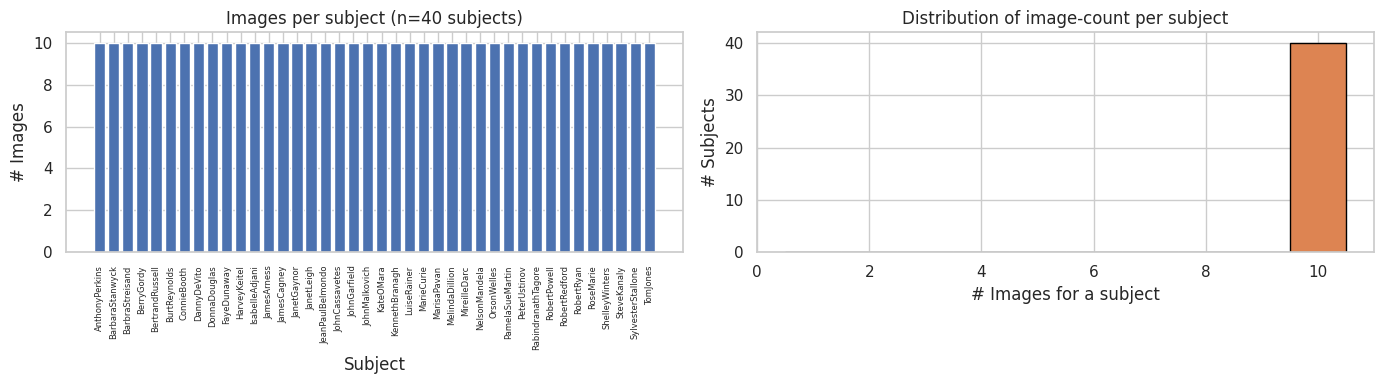

count    40.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: count, dtype: float64


In [5]:
counts = df["subject"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(counts.index.astype(str), counts.values, color="#4C72B0")
axes[0].set_title(f"Images per subject (n={df['subject'].nunique()} subjects)")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("# Images")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)

axes[1].hist(counts.values, bins=range(1, counts.max() + 2), color="#DD8452",
             edgecolor="black", align="left")
axes[1].set_title("Distribution of image-count per subject")
axes[1].set_xlabel("# Images for a subject")
axes[1].set_ylabel("# Subjects")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_data_distribution.png", dpi=150)
plt.show()

print(counts.describe())


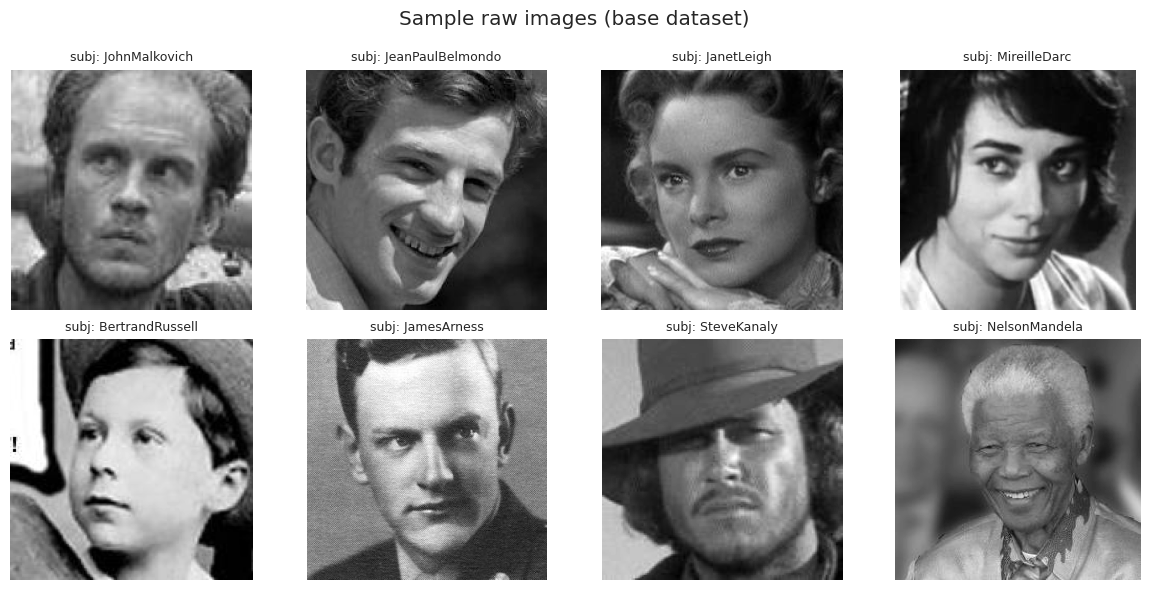

In [6]:
# Visual sample: a handful of raw images across different subjects
sample_paths = df.groupby("subject").first().reset_index().sample(8, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.flatten(), sample_paths.iterrows()):
    img = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"subj: {row['subject']}", fontsize=9)
    ax.axis("off")
plt.suptitle("Sample raw images (base dataset)")
plt.tight_layout()
plt.show()


## 4b. Age distribution (5-year classes)

Pipeline step: **Images (with age labels) -> Age distribution (5-year classes)**.

Every image gets an `age` (parsed from the AgeDB filename) and an `age_class` (5-year bins
such as `20-24`, `25-29`, ...). The plots show how the sampled images are spread across classes.

Age labels are read in this order: `AGE_LABELS_CSV` (optional) -> `AGE_FILENAME_REGEX` (default, AgeDB filenames)
-> simulated ages only if `ALLOW_SIMULATED_AGES=True` (disabled here since real labels exist).


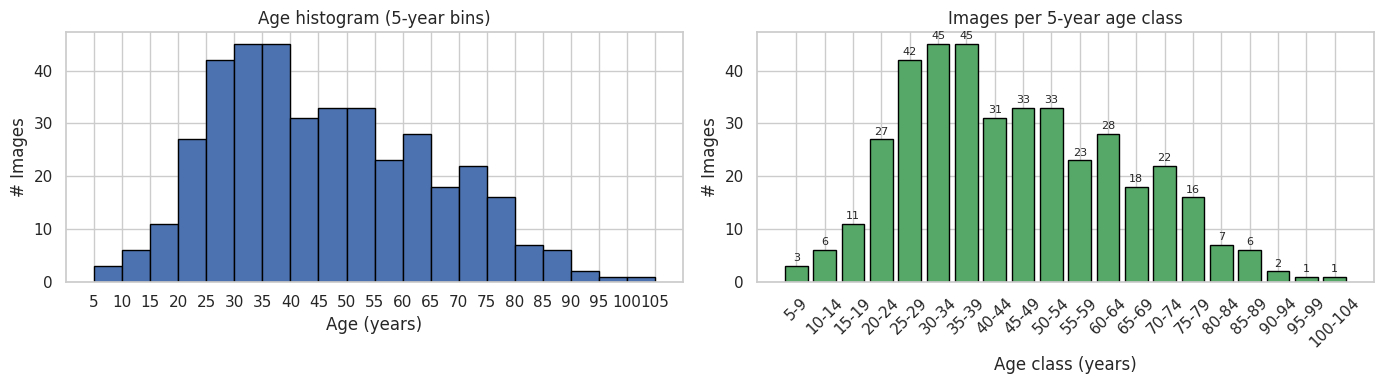

Age source: filename | min=6, max=100, mean=45.5


,images,subjects
age_class,,
5-9,3,3
10-14,6,6
15-19,11,10
20-24,27,22
25-29,42,30
30-34,45,31
35-39,45,31
40-44,31,26
45-49,33,28


In [7]:
# ---- Age-label config ----
AGE_LABELS_CSV          = None   # optional CSV with columns: `age` + (`path` [full or relative to DATA_ROOT] OR `filename`)
AGE_FILENAME_REGEX      = r"^\d+_.+_(\d{1,3})_[mfMF]\."   # AgeDB: 0_Name_32_f.jpg -> 32
ALLOW_SIMULATED_AGES    = False  # AgeDB has real age labels -> never simulate
AGE_BIN_WIDTH           = 5      # 5-year age classes

import re

def load_age_labels(df):
    df = df.copy()
    # 1) Explicit CSV of labels
    if AGE_LABELS_CSV and os.path.exists(AGE_LABELS_CSV):
        lab = pd.read_csv(AGE_LABELS_CSV)
        if "path" in lab.columns:
            rel = lambda p: os.path.normpath(os.path.relpath(p, DATA_ROOT)) if os.path.isabs(p) else os.path.normpath(p)
            m = dict(zip(lab["path"].map(rel), lab["age"]))
            df["age"] = df["path"].map(lambda p: m.get(os.path.normpath(os.path.relpath(p, DATA_ROOT))))
        else:
            m = dict(zip(lab["filename"], lab["age"]))
            df["age"] = df["path"].map(lambda p: m.get(os.path.basename(p)))
        df["age_source"] = "csv"
    # 2) Age encoded in the filename
    elif AGE_FILENAME_REGEX:
        def parse(p):
            mt = re.match(AGE_FILENAME_REGEX, os.path.basename(p))
            return int(mt.group(1)) if mt else np.nan
        df["age"] = df["path"].map(parse)
        df["age_source"] = "filename"
    else:
        df["age"] = np.nan

    # 3) Fallback: simulated ages (clearly flagged)
    if df["age"].isna().all():
        if not ALLOW_SIMULATED_AGES:
            raise RuntimeError("No age labels found. Provide AGE_LABELS_CSV / AGE_FILENAME_REGEX or set ALLOW_SIMULATED_AGES=True.")
        rng = np.random.default_rng(SEED)
        subj_age = {s: int(rng.integers(18, 71)) for s in sorted(df["subject"].unique())}
        # same person photographed over a short period -> small within-subject spread (0-2 yrs)
        df["age"] = df["subject"].map(subj_age) + rng.integers(0, 3, size=len(df))
        df["age_source"] = "SIMULATED"
        print("WARNING: no real age labels found -> using SIMULATED ages (demo only).")
        print("         Provide real labels via AGE_LABELS_CSV / AGE_FILENAME_REGEX for meaningful results.")
    elif df["age"].isna().any():
        print(f"WARNING: {df['age'].isna().sum()} images have no age label and will be dropped from age analysis.")
    return df

def make_age_classes(ages, width=AGE_BIN_WIDTH):
    lo = int(np.floor(ages.min() / width) * width)
    hi = int(np.ceil((ages.max() + 1) / width) * width)
    edges  = np.arange(lo, hi + width, width)
    labels = [f"{a}-{a + width - 1}" for a in edges[:-1]]
    return pd.cut(ages, bins=edges, labels=labels, right=False), edges, labels

df = load_age_labels(df)
df["age_class"], age_edges, age_labels = make_age_classes(df["age"])

age_counts = df["age_class"].value_counts().reindex(age_labels).fillna(0).astype(int)
tag = " [SIMULATED AGES]" if (df["age_source"] == "SIMULATED").any() else ""

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["age"].dropna(), bins=age_edges, color="#4C72B0", edgecolor="black", align="mid")
axes[0].set_title(f"Age histogram (5-year bins){tag}")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("# Images")
axes[0].set_xticks(age_edges)

bars = axes[1].bar(age_counts.index, age_counts.values, color="#55A868", edgecolor="black")
axes[1].bar_label(bars, padding=2, fontsize=8)
axes[1].set_title(f"Images per 5-year age class{tag}")
axes[1].set_xlabel("Age class (years)")
axes[1].set_ylabel("# Images")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01b_age_distribution.png", dpi=150)
plt.show()

age_table = (df.groupby("age_class", observed=False)
               .agg(images=("path", "size"), subjects=("subject", "nunique"))
               .reindex(age_labels))
age_table.to_csv(f"{OUT_DIR}/age_distribution.csv")
print(f"Age source: {df['age_source'].iloc[0]} | min={df['age'].min():.0f}, max={df['age'].max():.0f}, mean={df['age'].mean():.1f}")
age_table


## 5. MTCNN face detection

Runs MTCNN over every image to detect and crop/align the face. AgeDB images are
in-the-wild style crops, but MTCNN can
occasionally fail to detect a "face" confidently — in that case we fall back to a
simple center-crop/resize so the pipeline never drops a sample.


In [8]:
mtcnn = MTCNN(image_size=IMG_SIZE, margin=20, post_process=False, device=device)

def detect_and_align(gray_img):
    
    rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)
    try:
        face_tensor = mtcnn(rgb)  # returns a torch tensor in [0,255] or None
    except Exception:
        face_tensor = None

    if face_tensor is None:
        # Fallback: plain resize (keeps pipeline lossless for hard cases)
        resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        return resized.astype(np.uint8)

    face = face_tensor.permute(1, 2, 0).numpy()
    face = np.clip(face, 0, 255).astype(np.uint8)
    return face

# Detect once per image, cache to disk-in-memory (list) to avoid recomputation later
detected_faces = []
detect_failed  = 0
for p in df["path"]:
    gray = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    face = detect_and_align(gray)
    detected_faces.append(face)

df["_idx"] = range(len(df))
print(f"Processed {len(detected_faces)} images through MTCNN.")


Processed 400 images through MTCNN.


## 6. Pre-processing + noise injection (REAL / GAUSSIAN / SALT-PEPPER)

In [9]:
def add_gaussian_noise(img, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(img, amount=0.04, salt_ratio=0.5):
    noisy = img.copy()
    h, w = img.shape[:2]
    n_pixels = int(amount * h * w)

    n_salt = int(n_pixels * salt_ratio)
    ys = np.random.randint(0, h, n_salt); xs = np.random.randint(0, w, n_salt)
    noisy[ys, xs] = 255

    n_pepper = n_pixels - n_salt
    ys = np.random.randint(0, h, n_pepper); xs = np.random.randint(0, w, n_pepper)
    noisy[ys, xs] = 0
    return noisy

def make_variant(face_rgb, noise_type):
    if noise_type == "REAL":
        return face_rgb
    elif noise_type == "GAUSSIAN":
        return add_gaussian_noise(face_rgb)
    elif noise_type == "SALT_PEPPER":
        return add_salt_pepper_noise(face_rgb)
    else:
        raise ValueError(noise_type)

# Build variants for every image once (kept in memory; 400 imgs x 3 variants x 160x160x3 is small)
variants = {nt: [make_variant(f, nt) for f in detected_faces] for nt in NOISE_TYPES}
print("Variants built:", {k: len(v) for k, v in variants.items()})


Variants built: {'REAL': 400, 'GAUSSIAN': 400, 'SALT_PEPPER': 400}


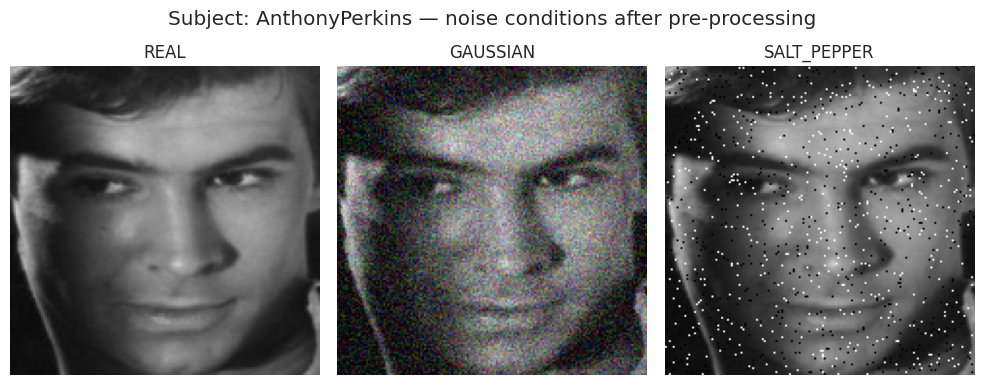

In [10]:
# Visual sanity check: same subject, three noise conditions
sample_i = 0
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, nt in zip(axes, NOISE_TYPES):
    ax.imshow(variants[nt][sample_i])
    ax.set_title(nt)
    ax.axis("off")
plt.suptitle(f"Subject: {df.iloc[sample_i]['subject']} — noise conditions after pre-processing")
plt.tight_layout()
plt.show()


## 7. FaceNet embeddings (with a lightweight PFE-style uncertainty proxy)

We use `InceptionResnetV1` pretrained on VGGFace2 (the standard "FaceNet" backbone
used in `facenet-pytorch`) to extract a 512-d embedding per face.

True **PFE (Probabilistic Face Embeddings)** trains a separate uncertainty head;
that's out of scope for a from-scratch Kaggle run. As a practical proxy we estimate
each embedding's **uncertainty (sigma)** via **MC-dropout-style perturbation**:
several forward passes with small input jitter, taking the per-dimension standard
deviation of the resulting embeddings. This gives an FMR/FNMR-relevant uncertainty
signal without training an extra network.


In [11]:
facenet = InceptionResnetV1(pretrained="vggface2").eval().to(device)

def to_tensor_batch(imgs_uint8):
    # imgs_uint8: list of HxWx3 uint8 arrays -> normalized batch tensor for facenet
    arr = np.stack(imgs_uint8).astype(np.float32)
    arr = (arr - 127.5) / 128.0                 # facenet-pytorch's expected normalization
    arr = np.transpose(arr, (0, 3, 1, 2))       # NHWC -> NCHW
    return torch.from_numpy(arr).to(device)

@torch.no_grad()
def embed_batch(imgs_uint8, batch_size=32):
    embs = []
    for i in range(0, len(imgs_uint8), batch_size):
        batch = to_tensor_batch(imgs_uint8[i:i + batch_size])
        out = facenet(batch).cpu().numpy()
        embs.append(out)
    return np.concatenate(embs, axis=0)

@torch.no_grad()
def embed_with_uncertainty(imgs_uint8, n_passes=5, jitter_std=2.0, batch_size=32):
    all_passes = []
    for _ in range(n_passes):
        jittered = [np.clip(im.astype(np.float32) + np.random.normal(0, jitter_std, im.shape), 0, 255).astype(np.uint8)
                    for im in imgs_uint8]
        all_passes.append(embed_batch(jittered, batch_size=batch_size))
    stacked = np.stack(all_passes, axis=0)      # (n_passes, N, 512)
    mean_emb = stacked.mean(axis=0)
    sigma    = stacked.std(axis=0).mean(axis=1) # scalar uncertainty per sample
    return mean_emb, sigma

embeddings   = {}
uncertainty  = {}
for nt in NOISE_TYPES:
    mean_emb, sigma = embed_with_uncertainty(variants[nt])
    embeddings[nt]  = mean_emb
    uncertainty[nt] = sigma
    print(f"{nt:12s} embeddings: {mean_emb.shape}, mean uncertainty(sigma)={sigma.mean():.3f}")


  0%|          | 0.00/107M [00:00<?, ?B/s]

REAL         embeddings: (400, 512), mean uncertainty(sigma)=0.001
GAUSSIAN     embeddings: (400, 512), mean uncertainty(sigma)=0.001
SALT_PEPPER  embeddings: (400, 512), mean uncertainty(sigma)=0.001


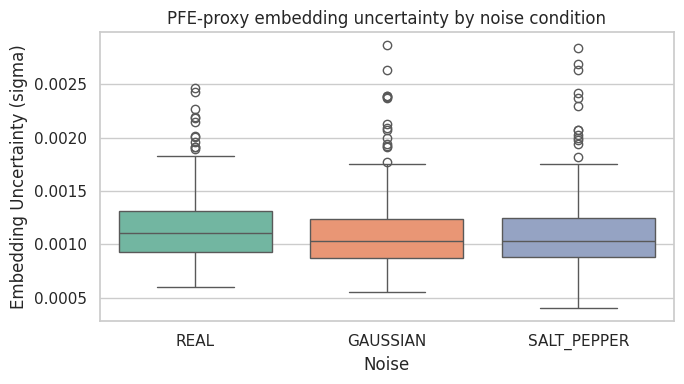

In [12]:
# Uncertainty (PFE proxy) by noise condition — sanity check that noise increases sigma
unc_df = pd.DataFrame({nt: uncertainty[nt] for nt in NOISE_TYPES})
unc_df_melt = unc_df.melt(var_name="Noise", value_name="Embedding Uncertainty (sigma)")

plt.figure(figsize=(7, 4))
sns.boxplot(data=unc_df_melt, x="Noise", y="Embedding Uncertainty (sigma)", hue="Noise", palette="Set2", legend=False)
plt.title("PFE-proxy embedding uncertainty by noise condition")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_embedding_uncertainty.png", dpi=150)
plt.show()


## 8. Genuine / Impostor pair generation

In [13]:
def build_pairs(df, max_genuine_per_subject=MAX_GENUINE_PAIRS_PER_SUBJECT,
                 max_impostor_per_subject=MAX_IMPOSTOR_PAIRS_PER_SUBJECT, seed=SEED):
    rng = random.Random(seed)
    idx_by_subject = df.groupby("subject")["_idx"].apply(list).to_dict()
    subjects = list(idx_by_subject.keys())

    genuine_pairs, impostor_pairs = [], []

    # Genuine: all (or a capped sample of) within-subject combinations
    for subj, idxs in idx_by_subject.items():
        combos = list(itertools.combinations(idxs, 2))
        rng.shuffle(combos)
        genuine_pairs.extend(combos[:max_genuine_per_subject])

    # Impostor: random cross-subject pairs, capped per subject
    for subj in subjects:
        other_subjects = [s for s in subjects if s != subj]
        a_idxs = idx_by_subject[subj]
        count = 0
        attempts = 0
        while count < max_impostor_per_subject and attempts < max_impostor_per_subject * 10:
            attempts += 1
            b_subj = rng.choice(other_subjects)
            a = rng.choice(a_idxs)
            b = rng.choice(idx_by_subject[b_subj])
            pair = (min(a, b), max(a, b))
            if pair not in impostor_pairs:
                impostor_pairs.append(pair)
                count += 1

    return genuine_pairs, impostor_pairs

genuine_pairs, impostor_pairs = build_pairs(df)
print(f"Genuine  pairs: {len(genuine_pairs)}")
print(f"Impostor pairs: {len(impostor_pairs)}")


Genuine  pairs: 800
Impostor pairs: 800


## 9. Similarity scores per noise condition

In [14]:
def cosine_sim(a, b):
    a = a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-9)
    b = b / (np.linalg.norm(b, axis=-1, keepdims=True) + 1e-9)
    return np.sum(a * b, axis=-1)

def score_pairs(emb, pairs):
    a_idx = np.array([p[0] for p in pairs])
    b_idx = np.array([p[1] for p in pairs])
    return cosine_sim(emb[a_idx], emb[b_idx])

scores = {}  # scores[noise_type] = {"genuine": np.array, "impostor": np.array}
for nt in NOISE_TYPES:
    g = score_pairs(embeddings[nt], genuine_pairs)
    i = score_pairs(embeddings[nt], impostor_pairs)
    scores[nt] = {"genuine": g, "impostor": i}
    print(f"{nt:12s} genuine mean={g.mean():.3f}  impostor mean={i.mean():.3f}")


REAL         genuine mean=0.572  impostor mean=0.084
GAUSSIAN     genuine mean=0.554  impostor mean=0.125
SALT_PEPPER  genuine mean=0.503  impostor mean=0.112


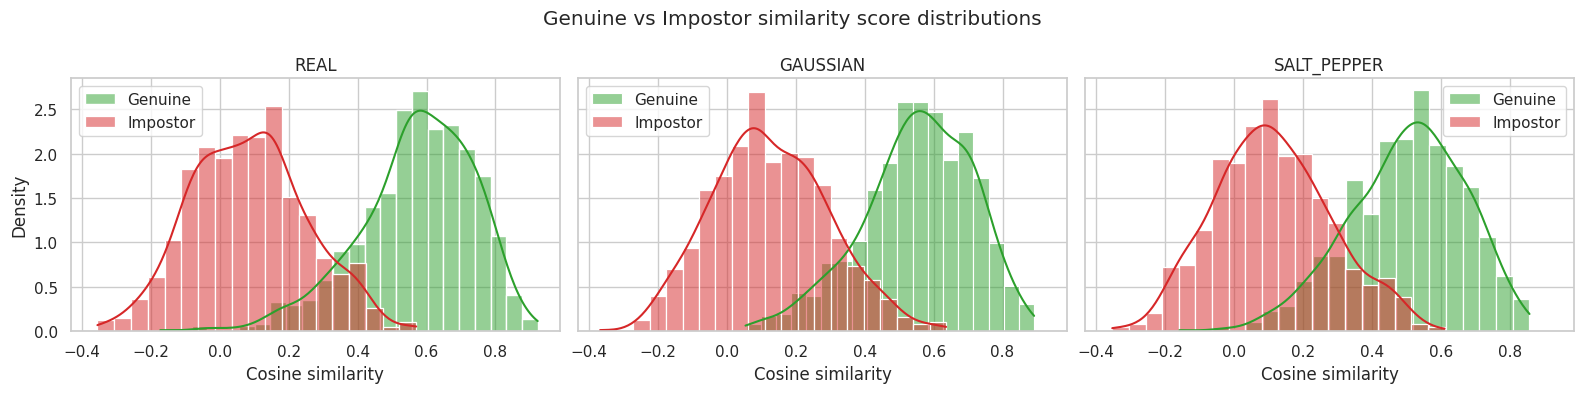

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)
for ax, nt in zip(axes, NOISE_TYPES):
    sns.histplot(scores[nt]["genuine"], color="#2ca02c", label="Genuine", stat="density",
                 kde=True, ax=ax, alpha=0.5)
    sns.histplot(scores[nt]["impostor"], color="#d62728", label="Impostor", stat="density",
                 kde=True, ax=ax, alpha=0.5)
    ax.set_title(nt)
    ax.set_xlabel("Cosine similarity")
    ax.legend()
plt.suptitle("Genuine vs Impostor similarity score distributions")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_score_distributions.png", dpi=150)
plt.show()


## 10. Evaluation — FMR, FNMR, EER, ROC/AUC

- **FMR(t)** = fraction of impostor pairs with similarity ≥ t (falsely accepted)
- **FNMR(t)** = fraction of genuine pairs with similarity < t (falsely rejected)
- **EER** = threshold where FMR(t) ≈ FNMR(t)


In [16]:
def compute_fmr_fnmr(genuine, impostor, n_thresholds=500):
    thresholds = np.linspace(-1, 1, n_thresholds)
    fmr  = np.array([(impostor >= t).mean() for t in thresholds])
    fnmr = np.array([(genuine  <  t).mean() for t in thresholds])
    return thresholds, fmr, fnmr

def find_eer(thresholds, fmr, fnmr):
    diffs = np.abs(fmr - fnmr)
    idx = np.argmin(diffs)
    eer = (fmr[idx] + fnmr[idx]) / 2
    return eer, thresholds[idx]

results_summary = []
curves = {}
for nt in NOISE_TYPES:
    thresholds, fmr, fnmr = compute_fmr_fnmr(scores[nt]["genuine"], scores[nt]["impostor"])
    eer, eer_thresh = find_eer(thresholds, fmr, fnmr)

    y_true  = np.concatenate([np.ones_like(scores[nt]["genuine"]), np.zeros_like(scores[nt]["impostor"])])
    y_score = np.concatenate([scores[nt]["genuine"], scores[nt]["impostor"]])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    curves[nt] = {"thresholds": thresholds, "fmr": fmr, "fnmr": fnmr,
                  "fpr": fpr, "tpr": tpr}
    results_summary.append({
        "Noise": nt,
        "EER": round(eer, 4),
        "EER Threshold": round(eer_thresh, 4),
        "AUC": round(roc_auc, 4),
        "Mean Genuine Score": round(scores[nt]["genuine"].mean(), 4),
        "Mean Impostor Score": round(scores[nt]["impostor"].mean(), 4),
    })

results_df = pd.DataFrame(results_summary)
results_df


,Noise,EER,EER Threshold,AUC,Mean Genuine Score,Mean Impostor Score
0,REAL,0.0862,0.3267,0.9733,0.5718,0.0844
1,GAUSSIAN,0.1050,0.3427,0.9617,0.5536,0.1255
2,SALT_PEPPER,0.1281,0.3106,0.9435,0.5032,0.1122


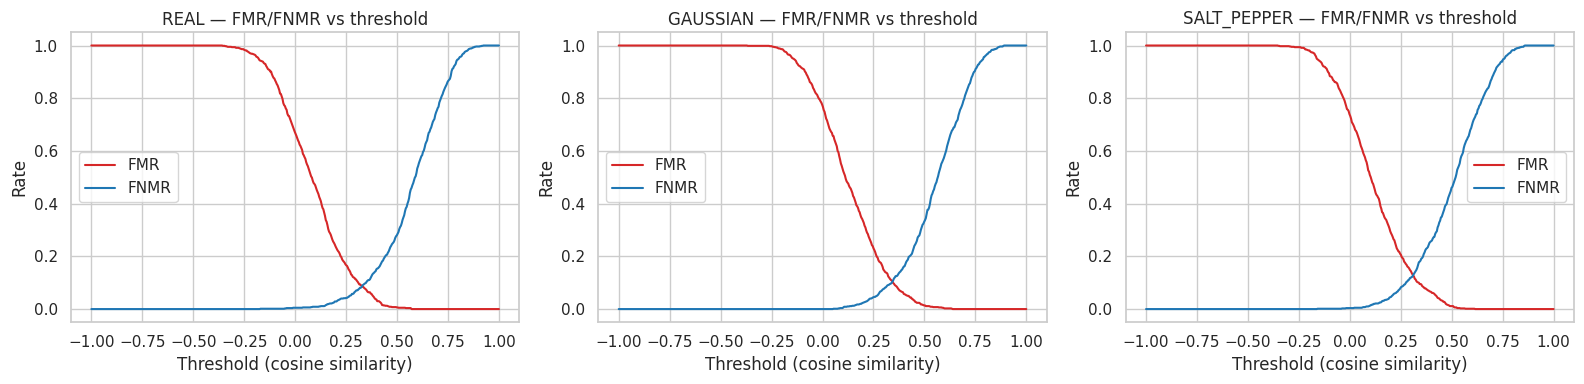

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, nt in zip(axes, NOISE_TYPES):
    c = curves[nt]
    ax.plot(c["thresholds"], c["fmr"], label="FMR", color="#d62728")
    ax.plot(c["thresholds"], c["fnmr"], label="FNMR", color="#1f77b4")
    ax.set_title(f"{nt} — FMR/FNMR vs threshold")
    ax.set_xlabel("Threshold (cosine similarity)")
    ax.set_ylabel("Rate")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_fmr_fnmr_curves.png", dpi=150)
plt.show()


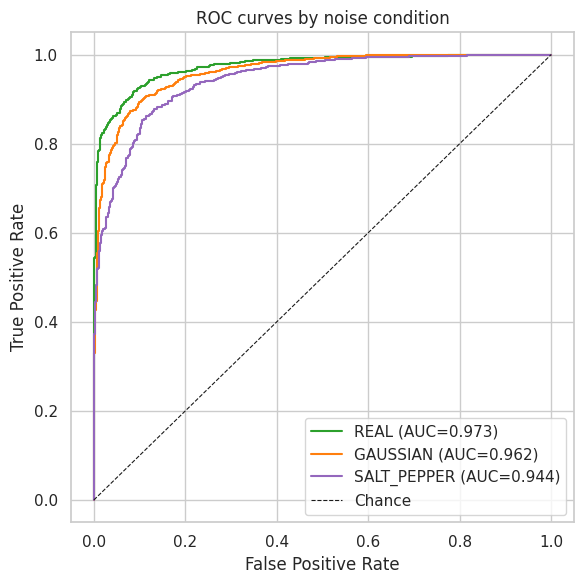

In [18]:
plt.figure(figsize=(6, 6))
colors = {"REAL": "#2ca02c", "GAUSSIAN": "#ff7f0e", "SALT_PEPPER": "#9467bd"}
for nt in NOISE_TYPES:
    c = curves[nt]
    row = results_df.loc[results_df["Noise"] == nt].iloc[0]
    plt.plot(c["fpr"], c["tpr"], label=f"{nt} (AUC={row['AUC']:.3f})", color=colors[nt])
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves by noise condition")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_roc_curves.png", dpi=150)
plt.show()


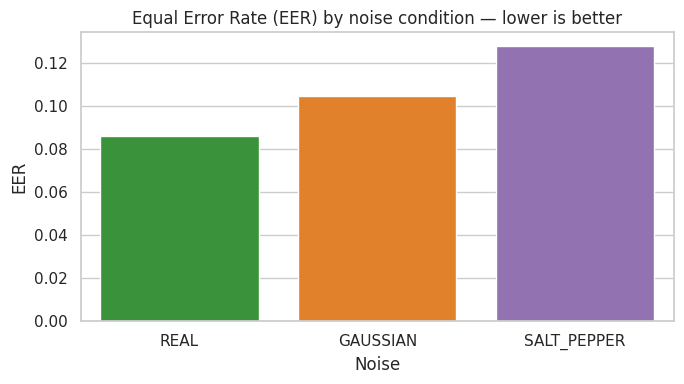

In [19]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="Noise", y="EER", hue="Noise", legend=False, palette=[colors[n] for n in results_df["Noise"]])
plt.title("Equal Error Rate (EER) by noise condition — lower is better")
plt.ylabel("EER")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_eer_comparison.png", dpi=150)
plt.show()


## 11. Results summary

In [20]:
results_df.to_csv(f"{OUT_DIR}/results_summary.csv", index=False)
print(f"Saved: {OUT_DIR}/results_summary.csv")
print()
print(results_df.to_string(index=False))


Saved: /kaggle/working/results/results_summary.csv

      Noise    EER  EER Threshold    AUC  Mean Genuine Score  Mean Impostor Score
       REAL 0.0862         0.3267 0.9733              0.5718               0.0844
   GAUSSIAN 0.1050         0.3427 0.9617              0.5536               0.1255
SALT_PEPPER 0.1281         0.3106 0.9435              0.5032               0.1122


### Tuning knobs
- `add_gaussian_noise(sigma=...)` / `add_salt_pepper_noise(amount=...)` — noise severity.
- `MAX_GENUINE_PAIRS_PER_SUBJECT` / `MAX_IMPOSTOR_PAIRS_PER_SUBJECT` — pair-count balance.
- `n_passes` / `jitter_std` in `embed_with_uncertainty` — PFE-proxy sensitivity.
